Total Jobs: 663


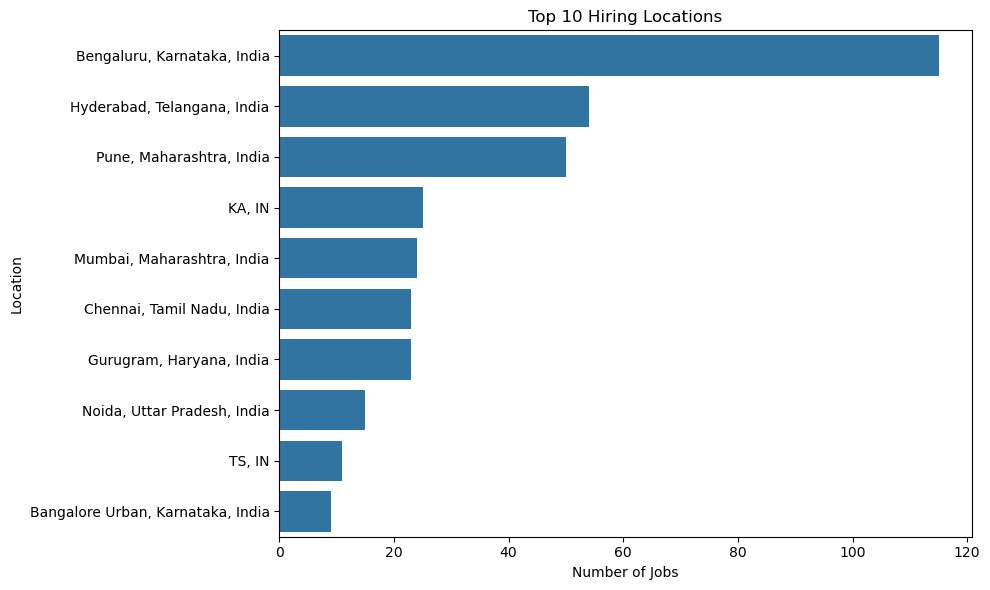

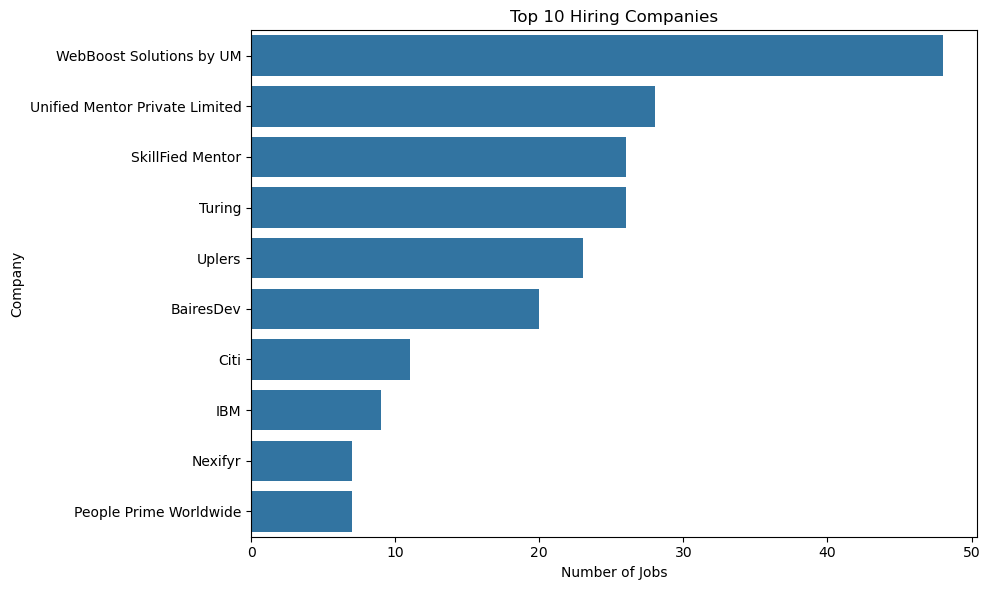

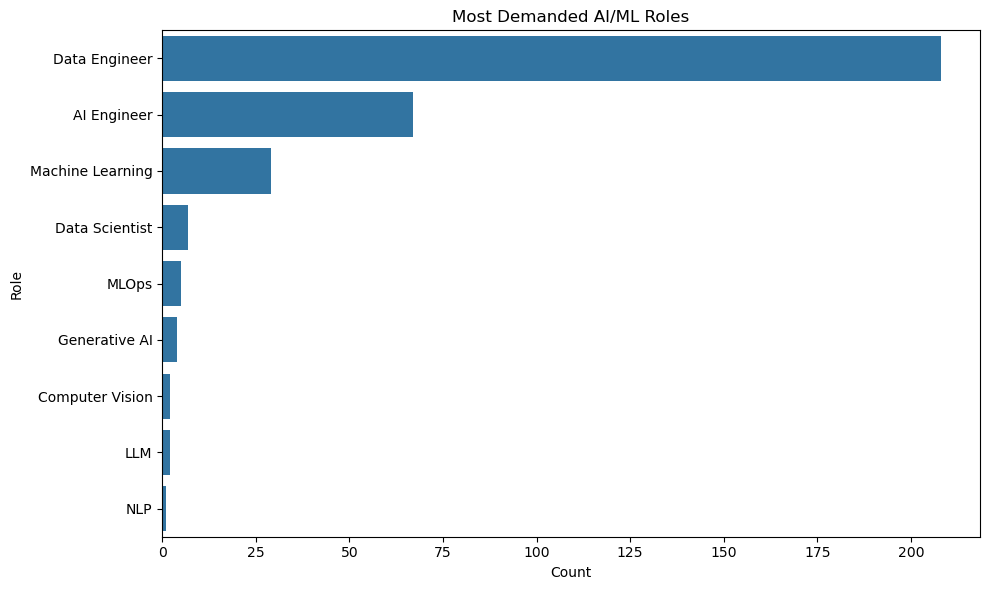

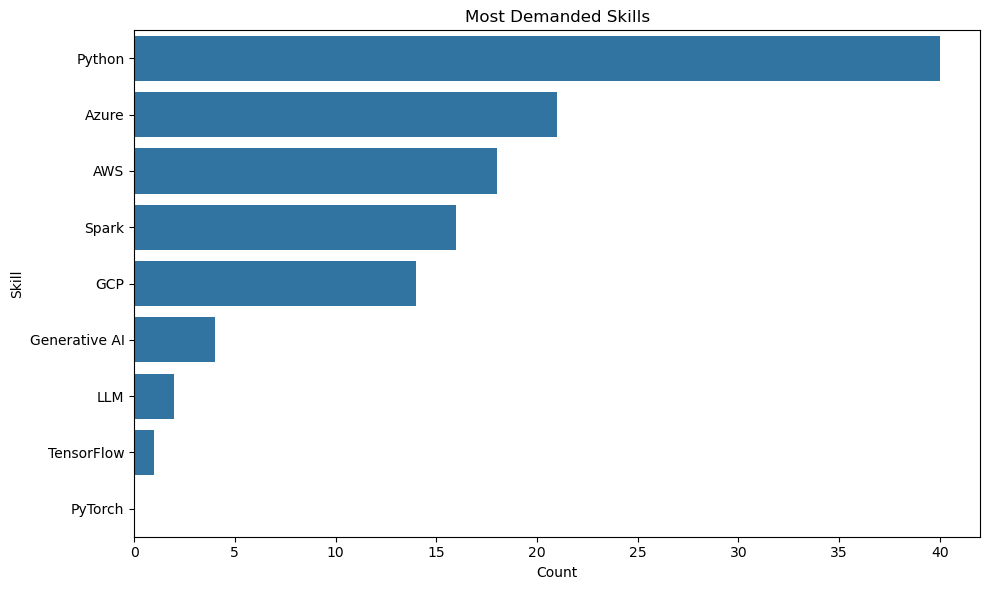


===== DATASET SUMMARY =====
Total Unique Jobs: 663

Top Locations:
location
Bengaluru, Karnataka, India          115
Hyderabad, Telangana, India           54
Pune, Maharashtra, India              50
KA, IN                                25
Mumbai, Maharashtra, India            24
Chennai, Tamil Nadu, India            23
Gurugram, Haryana, India              23
Noida, Uttar Pradesh, India           15
TS, IN                                11
Bangalore Urban, Karnataka, India      9
Name: count, dtype: int64

Top Companies:
company
WebBoost Solutions by UM          48
Unified Mentor Private Limited    28
SkillFied Mentor                  26
Turing                            26
Uplers                            23
BairesDev                         20
Citi                              11
IBM                                9
Nexifyr                            7
People Prime Worldwide             7
Name: count, dtype: int64

Top Roles:
               Role  Count
3     Data Engineer    208
0

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import re

zip_path = "AI & ML Job Market Analysis(16_6_26).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("job_data")

jobs1 = pd.read_csv("job_data/jobs_main.csv")
jobs2 = pd.read_csv("job_data/merged_jobs.csv")

df = pd.concat([jobs1, jobs2], ignore_index=True)

if 'job_url' in df.columns:
    df = df.drop_duplicates(subset='job_url')

print("Total Jobs:", len(df))

location_counts = (
    df['location']
    .dropna()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))
sns.barplot(
    x=location_counts.values,
    y=location_counts.index
)
plt.title("Top 10 Hiring Locations")
plt.xlabel("Number of Jobs")
plt.ylabel("Location")
plt.tight_layout()
plt.show()

company_counts = (
    df['company']
    .dropna()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))
sns.barplot(
    x=company_counts.values,
    y=company_counts.index
)
plt.title("Top 10 Hiring Companies")
plt.xlabel("Number of Jobs")
plt.ylabel("Company")
plt.tight_layout()
plt.show()

role_keywords = {
    "AI Engineer": r"ai engineer",
    "Machine Learning": r"machine learning|ml engineer",
    "Data Scientist": r"data scientist",
    "Data Engineer": r"data engineer",
    "Computer Vision": r"computer vision",
    "NLP": r"nlp|natural language",
    "MLOps": r"mlops",
    "Generative AI": r"generative ai",
    "LLM": r"\bllm\b"
}

role_counts = {}

for role, pattern in role_keywords.items():
    count = df['title'].str.contains(
        pattern,
        case=False,
        na=False,
        regex=True
    ).sum()

    role_counts[role] = count

role_df = pd.DataFrame(
    role_counts.items(),
    columns=['Role', 'Count']
).sort_values(
    by='Count',
    ascending=False
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=role_df,
    x='Count',
    y='Role'
)
plt.title("Most Demanded AI/ML Roles")
plt.tight_layout()
plt.show()


skills = [
    "Python",
    "AWS",
    "Azure",
    "GCP",
    "Spark",
    "TensorFlow",
    "PyTorch",
    "LLM",
    "Generative AI"
]

skill_counts = {}

for skill in skills:
    count = df['title'].astype(str).str.contains(
        skill,
        case=False,
        na=False
    ).sum()

    skill_counts[skill] = count

skill_df = pd.DataFrame(
    skill_counts.items(),
    columns=['Skill', 'Count']
).sort_values(
    by='Count',
    ascending=False
)

plt.figure(figsize=(10,6))
sns.barplot(
    data=skill_df,
    x='Count',
    y='Skill'
)
plt.title("Most Demanded Skills")
plt.tight_layout()
plt.show()


print("\n===== DATASET SUMMARY =====")
print("Total Unique Jobs:", len(df))
print("\nTop Locations:")
print(location_counts)

print("\nTop Companies:")
print(company_counts)

print("\nTop Roles:")
print(role_df)

print("\nTop Skills:")
print(skill_df)